# Controlled-NOT Gate and Controlled Bit Flip

## 1. Objective
The objective of this experiment is to demonstrate the operational behavior of the 2-qubit **Controlled-NOT (CNOT)** gate. Specifically, the experiment prepares the control qubit in state $|1\rangle$ using a Pauli-X gate and verifies that the CNOT gate conditionally flips the target qubit from $|0\rangle$ to $|1\rangle$.

---

## 2. Theory

### Multi-Qubit Computational Basis
A 2-qubit quantum register is initialized by default in the product ground state:

$$|00\rangle = |0\rangle \otimes |0\rangle = \begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix}$$

### Pauli-X Preparation on the Control Qubit
The single-qubit **Pauli-X gate** is a bit-flip operator. Applying $X$ to qubit 0 transforms its state from $|0\rangle$ to $|1\rangle$:

$$X|0\rangle = |1\rangle$$

This prepares the intermediate 2-qubit state $|10\rangle$ (where qubit 0 is $|1\rangle$ and qubit 1 is $|0\rangle$).

### Controlled-NOT (CNOT) Gate Mechanics
The **CNOT gate** (represented by the unitary matrix $CX$) is a fundamental 2-qubit conditional gate operating on a **control qubit** and a **target qubit**:

$$CX = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}$$

The operation of CNOT is defined conditionally:
- If the control qubit is $|0\rangle$, the target qubit remains unchanged.
- If the control qubit is $|1\rangle$, a Pauli-X (bit-flip) gate is applied to the target qubit:
  $$|00\rangle \xrightarrow{\quad CX \quad} |00\rangle$$
  $$|01\rangle \xrightarrow{\quad CX \quad} |01\rangle$$
  $$|10\rangle \xrightarrow{\quad CX \quad} |11\rangle$$
  $$|11\rangle \xrightarrow{\quad CX \quad} |10\rangle$$

In this experiment, because qubit 0 (control) is explicitly prepared in $|1\rangle$ and qubit 1 (target) is in $|0\rangle$, the CNOT gate deterministically flips qubit 1 to $|1\rangle$, producing the final state $|11\rangle$.

### Measurement Outcome
Measuring both qubits in the computational basis collapses the deterministic state $|11\rangle$ into classical outcome `11` with $100\%$ theoretical probability in the ideal simulation.

## 3. Circuit Construction
The sequence of operations across the two qubits is:

$$|00\rangle \xrightarrow{\quad X \text{ on qubit 0} \quad} |10\rangle \xrightarrow{\quad \text{CNOT(control=q0, target=q1)} \quad} |11\rangle$$

- **Qubit 0 (`q0`)**: Acts as the **control qubit**. It is flipped from $|0\rangle$ to $|1\rangle$ via `qc.x(0)`.
- **Qubit 1 (`q1`)**: Acts as the **target qubit**. It is initialized in $|0\rangle$ and flipped to $|1\rangle$ by `qc.cx(0, 1)`.
- **Measurement Operations**: Qubit 0 is measured into classical bit 0 (`qc.measure(0, 0)`), and qubit 1 is measured into classical bit 1 (`qc.measure(1, 1)`).

### Environment Setup
Install Qiskit, Qiskit Aer, and Matplotlib if executing in a fresh environment.

In [1]:
pip install qiskit qiskit-aer matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 4. Simulation and Measurement
- **Simulation Backend**: The circuit is simulated using Qiskit Aer's `AerSimulator()`, modeling an ideal quantum processor.
- **Execution Shots**: The circuit is executed with 1024 shots.
- **Count Extraction**: The measured counts are extracted using `result.get_counts()`.
- **Visualization**: The distribution over all four 2-qubit computational basis states (`'00'`, `'01'`, `'10'`, `'11'`) is displayed numerically and visualized using a Matplotlib bar chart.
- **Validation**: A conditional statement checks that all 1024 shots produced state `'11'`.

/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2531/4102278289.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


CNOT Circuit
     ┌───┐     ┌─┐   
q_0: ┤ X ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

Measurement Results:
{'11': 1024}


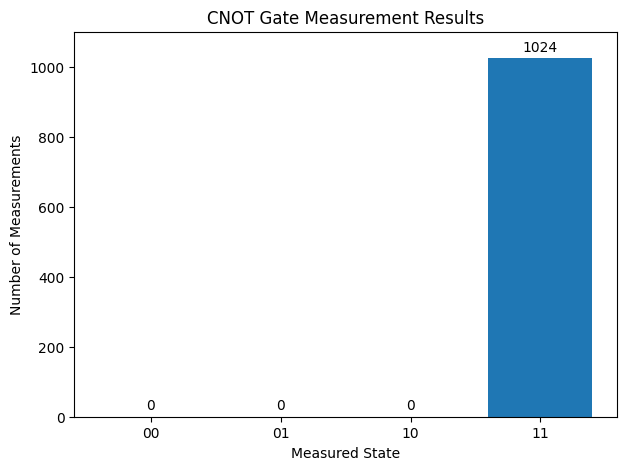


Target qubit successfully flipped.


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

qc = QuantumCircuit(2, 2)

qc.x(0)
qc.cx(0, 1)

qc.measure(0, 0)
qc.measure(1, 1)

print("CNOT Circuit")
print(qc.draw())

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("\nMeasurement Results:")
print(counts)

states = ['00', '01', '10', '11']
values = [counts.get(state, 0) for state in states]

plt.figure(figsize=(7, 5))
plt.bar(states, values)
plt.xlabel("Measured State")
plt.ylabel("Number of Measurements")
plt.title("CNOT Gate Measurement Results")
plt.ylim(0, 1100)

for i, value in enumerate(values):
    plt.text(i, value + 20, str(value), ha='center')

plt.show()

if counts.get('11', 0) == 1024:
    print("\nTarget qubit successfully flipped.")
else:
    print("\nUnexpected result.")

## 5. Results & Observations

### Circuit Structure
The circuit diagram confirms the sequential gate application:
```
     ┌───┐     ┌─┐   
q_0: ┤ X ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 
```

### Measurement Results
- **Numerical Output**:
  ```
  Measurement Results:
  {'11': 1024}
  ```
- **Distribution Analysis**: All 1024 shots produced the bitstring `11`, while states `00`, `01`, and `10` received zero counts.
- **Deterministic Behavior**: Because the control qubit is deterministically prepared in $|1\rangle$ before the CNOT operation without superposition or noise, the target qubit is flipped with $100\%$ probability.
- **Confirmation Message**: The program successfully confirms:
  ```
  Target qubit successfully flipped.
  ```

## 6. Conclusion
This experiment clearly demonstrates the conditional behavior of the CNOT gate: when the control qubit is in $|1\rangle$, the target qubit is deterministically flipped from $|0\rangle$ to $|1\rangle$. Executing the circuit in an ideal simulation verifies that $100\%$ of the 1024 measurement shots yield the bitstring `11`, confirming the logic of the controlled bit-flip operation.